In [1]:
library(tidyverse)

Warning message:
"package 'ggplot2' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
data <- read.csv("cardiovascular_disease_data.csv")
head(data)
summary(data)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

In [3]:
data$Gender = as.factor(data$Gender)
data$Smoking_Status = as.factor(data$Smoking_Status)
data$Alcohol_Consumption = as.factor(data$Alcohol_Consumption)
data$Physical_Activity_Level = as.factor(data$Physical_Activity_Level)
data$Family_History = as.factor(data$Family_History)
data$Stress_Level = as.factor(data$Stress_Level)
data$Sleep_Hours = as.factor(data$Sleep_Hours)
data$Heart_Disease_Risk = as.factor(data$Heart_Disease_Risk)

In [4]:
# change patient ID to index

data = data %>% column_to_rownames(., var="Patient_ID")

In [5]:
summary(data)

      Age        Gender     Height_cm       Weight_kg           BMI       
 Min.   :25.00   0:7622   Min.   :138.5   Min.   : 33.70   Min.   :14.50  
 1st Qu.:46.00   1:7378   1st Qu.:158.5   1st Qu.: 65.20   1st Qu.:24.50  
 Median :55.00            Median :164.7   Median : 73.90   Median :27.20  
 Mean   :54.54            Mean   :165.3   Mean   : 75.25   Mean   :27.45  
 3rd Qu.:63.00            3rd Qu.:172.0   3rd Qu.: 83.90   3rd Qu.:30.00  
 Max.   :85.00            Max.   :198.1   Max.   :150.10   Max.   :46.10  
                                                                          
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0     3rd Qu.:

# Prepare data

In [6]:
# list of quantitative variable

numeric_cols <- names(data)[sapply(data, is.numeric)]
numeric_cols

[1] "Age"                 "Height_cm"           "Weight_kg"          
 [4] "BMI"                 "Systolic_BP"         "Diastolic_BP"       
 [7] "Cholesterol_Total"   "Cholesterol_LDL"     "Cholesterol_HDL"    
[10] "Fasting_Blood_Sugar"

In [7]:
# List of qualitative variables

categorical_cols <- names(data)[sapply(data, is.factor)]
categorical_cols

[1] "Gender"                  "Smoking_Status"         
[3] "Alcohol_Consumption"     "Physical_Activity_Level"
[5] "Family_History"          "Stress_Level"           
[7] "Sleep_Hours"             "Heart_Disease_Risk"

**Important!!!**

We will use the function $\textit{createDataPartition}$ in the package $\textit{caret}$ to create the train data and test data. Before doing any analysis, we need to rescale the qualitative variables, since they have different scales.

In [8]:
#install.packages('caret')

In [9]:
library(caret)

Warning message:
"package 'caret' was built under R version 4.4.3"
Loading required package: lattice


Attaching package: 'caret'


The following object is masked from 'package:purrr':

    lift




In [10]:
#help(createDataPartition)

In [11]:
set.seed(111)
### Create dataset for Heart disease risk
train_id_H <- createDataPartition(data$Heart_Disease_Risk, p = 0.8, list = FALSE)
trainH <- data[train_id_H, ]
testH  <- data[-train_id_H, ]

# estimate scaling on training only
preproc <- preProcess(trainH[, numeric_cols], method = c("center", "scale"))

#apply the center and scale on the train and test data
train_scaledH <- predict(preproc, trainH)
test_scaledH  <- predict(preproc, testH)

In [12]:
dim(train_scaledH)
dim(test_scaledH)

[1] 12000    18

[1] 3000   18

In [13]:
summary(train_scaledH)
summary(test_scaledH)

      Age          Gender     Height_cm          Weight_kg      
 Min.   :-2.4949   0:6085   Min.   :-2.92900   Min.   :-2.6069  
 1st Qu.:-0.7210   1:5915   1st Qu.:-0.74765   1st Qu.:-0.7106  
 Median : 0.0392            Median :-0.06053   Median :-0.1020  
 Mean   : 0.0000            Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.: 0.7150            3rd Qu.: 0.73566   3rd Qu.: 0.6127  
 Max.   : 2.5733            Max.   : 3.53869   Max.   : 5.2970  
                                                                
      BMI            Systolic_BP         Diastolic_BP      Cholesterol_Total 
 Min.   :-3.12711   Min.   :-3.993653   Min.   :-3.60776   Min.   :-3.94837  
 1st Qu.:-0.70976   1st Qu.:-0.716731   1st Qu.:-0.65306   1st Qu.:-0.67555  
 Median :-0.05708   Median :-0.008207   Median : 0.05607   Median :-0.01214  
 Mean   : 0.00000   Mean   : 0.000000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.61978   3rd Qu.: 0.700317   3rd Qu.: 0.64701   3rd Qu.: 0.65127  
 Max.   : 4.

      Age             Gender     Height_cm           Weight_kg        
 Min.   :-2.4948786   0:1537   Min.   :-2.928998   Min.   :-2.939519  
 1st Qu.:-0.6576710   1:1463   1st Qu.:-0.758559   1st Qu.:-0.710566  
 Median :-0.0452685            Median :-0.087796   Median :-0.063108  
 Mean   : 0.0009362            Mean   :-0.009925   Mean   : 0.003791  
 3rd Qu.: 0.7149553            3rd Qu.: 0.713849   3rd Qu.: 0.640958  
 Max.   : 2.5732803            Max.   : 3.571411   Max.   : 3.782720  
                                                                      
      BMI            Systolic_BP         Diastolic_BP       Cholesterol_Total 
 Min.   :-2.93372   Min.   :-3.550826   Min.   :-3.607762   Min.   :-3.19651  
 1st Qu.:-0.68559   1st Qu.:-0.628165   1st Qu.:-0.653058   1st Qu.:-0.71978  
 Median :-0.05708   Median :-0.008207   Median : 0.056070   Median :-0.01214  
 Mean   : 0.01203   Mean   : 0.011071   Mean   : 0.009268   Mean   :-0.00586  
 3rd Qu.: 0.61978   3rd Qu.: 0.611751

# Heart disease risk

In order to compare the efficiency of each method, we need to find an indicator. For python the default score is the accuracy, i.e. (True pos + True neg)/total samples. However if we want to minimize the risk of saying a patient is healthy while he/she has a heart disease, we need to minimize false negative rate, i.e. maximize sensitivity (True pos / total real pos).

## Logistic regression

In [14]:
#help(glm)

In [15]:
res.log = glm(Heart_Disease_Risk~., family="binomial", data=train_scaledH)

In [16]:
summary(res.log)


Call:
glm(formula = Heart_Disease_Risk ~ ., family = "binomial", data = train_scaledH)

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -0.626088   0.133525  -4.689 2.75e-06 ***
Age                       0.238790   0.026454   9.027  < 2e-16 ***
Gender1                  -0.079463   0.065148  -1.220 0.222569    
Height_cm                -0.109672   0.145465  -0.754 0.450882    
Weight_kg                 0.234297   0.238019   0.984 0.324936    
BMI                       0.007564   0.192897   0.039 0.968722    
Systolic_BP               0.338780   0.038537   8.791  < 2e-16 ***
Diastolic_BP             -0.008522   0.036767  -0.232 0.816711    
Cholesterol_Total        -0.047562   0.040718  -1.168 0.242780    
Cholesterol_LDL           0.209804   0.039084   5.368 7.96e-08 ***
Cholesterol_HDL          -0.057802   0.026068  -2.217 0.026600 *  
Fasting_Blood_Sugar       0.328644   0.022890  14.358  < 2e-16 ***
Smoking_Status1           

**Comment** : We can observe the significance of the parameters. It seems that the risk of having heart disease depends on Age, Systolic BP, Cholesterol_LDL, Fasting blood sugar, Smoking status, Physical activity level, Family history, Stress level and Sleep hours. This result is coherent with the exploratory analysis.

In [17]:
pred.log <- predict(res.log, newdata = test_scaledH, type = "response")
# Matrice de confusion pour la prévision du 
# dépassement de seuil
table(pred.log > 0.5, test_scaledH[, "Heart_Disease_Risk"])

       
           0    1
  FALSE 1397  488
  TRUE   295  820

### Logistic regression - AIC

In [18]:
#help(step)

In [19]:
res.log.aic = step(res.log, direction='backward')

Start:  AIC=12682.92
Heart_Disease_Risk ~ Age + Gender + Height_cm + Weight_kg + BMI + 
    Systolic_BP + Diastolic_BP + Cholesterol_Total + Cholesterol_LDL + 
    Cholesterol_HDL + Fasting_Blood_Sugar + Smoking_Status + 
    Alcohol_Consumption + Physical_Activity_Level + Family_History + 
    Stress_Level + Sleep_Hours

                          Df Deviance   AIC
- BMI                      1    12615 12681
- Diastolic_BP             1    12615 12681
- Alcohol_Consumption      2    12617 12681
- Height_cm                1    12616 12682
- Weight_kg                1    12616 12682
- Cholesterol_Total        1    12616 12682
- Gender                   1    12616 12682
<none>                          12615 12683
- Cholesterol_HDL          1    12620 12686
- Sleep_Hours              6    12636 12692
- Cholesterol_LDL          1    12644 12710
- Systolic_BP              1    12693 12759
- Age                      1    12697 12763
- Stress_Level             9    12796 12846
- Fasting_Blood_

In [33]:
pred.log <- predict(res.log.aic, newdata = test_scaledH, type = "response")
# Matrice de confusion pour la prévision du 
# dépassement de seuil
table(pred.log > 0.5, test_scaledH[, "Heart_Disease_Risk"])

# sensitivity
sum(pred.log >0.5 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

       
           0    1
  FALSE 1394  483
  TRUE   298  825

[1] 0.6307339

In [21]:
summary(res.log.aic)


Call:
glm(formula = Heart_Disease_Risk ~ Age + Height_cm + Weight_kg + 
    Systolic_BP + Cholesterol_LDL + Cholesterol_HDL + Fasting_Blood_Sugar + 
    Smoking_Status + Physical_Activity_Level + Family_History + 
    Stress_Level + Sleep_Hours, family = "binomial", data = train_scaledH)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -0.68918    0.12831  -5.371 7.83e-08 ***
Age                       0.23096    0.02567   8.999  < 2e-16 ***
Height_cm                -0.13899    0.02758  -5.039 4.67e-07 ***
Weight_kg                 0.24293    0.03041   7.988 1.37e-15 ***
Systolic_BP               0.33263    0.02480  13.415  < 2e-16 ***
Cholesterol_LDL           0.17355    0.02380   7.292 3.05e-13 ***
Cholesterol_HDL          -0.04718    0.02456  -1.921 0.054737 .  
Fasting_Blood_Sugar       0.32846    0.02288  14.356  < 2e-16 ***
Smoking_Status1           1.97893    0.04997  39.599  < 2e-16 ***
Physical_Activity_Level1 -0.58578  

In [22]:
anova(res.log.aic, test = "Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16438.38,NA
Age,1,341.4117701,11998,16096.97,3.143504e-76
Height_cm,1,0.4077415,11997,16096.56,5.231180e-01
Weight_kg,1,215.7135281,11996,15880.85,7.787776e-49
Systolic_BP,1,158.6956416,11995,15722.16,2.180931e-36
Cholesterol_LDL,1,43.1503646,11994,15679.00,5.069045e-11
Cholesterol_HDL,1,3.0627434,11993,15675.94,8.010631e-02
Fasting_Blood_Sugar,1,173.2186608,11992,15502.72,1.466278e-39
Smoking_Status,1,1640.2029765,11991,13862.52,0.000000e+00


In [23]:
# Test of sub model : verify if the submodel is efficient enough

anova(res.log.aic, res.log, test = "Chisq")

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,11972,12619.96,NA,NA,NA
2,11966,12614.92,6,5.040519,0.5386269


**Comment:** According to the submodel test, we conclude that we can replace the complete model by submodel.

In [24]:
# Odd ratio
as.table(exp(res.log.aic$coefficients))

             (Intercept)                      Age                Height_cm 
               0.5019899                1.2598067                0.8702326 
               Weight_kg              Systolic_BP          Cholesterol_LDL 
               1.2749839                1.3946349                1.1895251 
         Cholesterol_HDL      Fasting_Blood_Sugar          Smoking_Status1 
               0.9539199                1.3888291                7.2350257 
Physical_Activity_Level1 Physical_Activity_Level2 Physical_Activity_Level3 
               0.5566700                0.3285257                0.2080596 
         Family_History1            Stress_Level2            Stress_Level3 
               4.3785904                1.0717692                1.2592304 
           Stress_Level4            Stress_Level5            Stress_Level6 
               1.3729118                1.4695132                1.7781442 
           Stress_Level7            Stress_Level8            Stress_Level9 
            

**Comments:**
- A smoking person can have about 7 times higher risk of having cardiovascular diseases compared to non-smoking person.
- For a person which family history had a heart disease patient, the odds of having the disease is about 4 times higher than those not having any in the family history.
- The stress level increases the risk, while the sleep hour reduces it.
- ...

In [25]:
library(ROCR)

Warning message:
"package 'ROCR' was built under R version 4.4.3"


In [26]:
roclogit <- predict(res.log.aic, newdata = test_scaledH, type="response")
predlogit <- prediction(roclogit, test_scaledH[, "Heart_Disease_Risk"])
perflogit <- performance(predlogit, "tpr", "fpr")

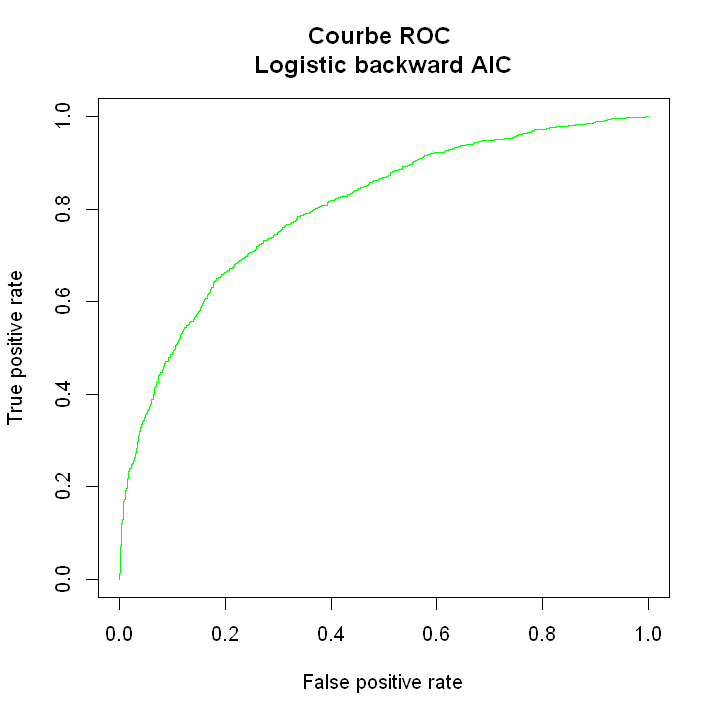

In [27]:
options(repr.plot.width = 6, repr.plot.height = 6)
plot(perflogit,col="green",lty=1, main = "Courbe ROC \n Logistic backward AIC ") 

## LDA

In [34]:
library(glmnet)
library(MASS)

In [35]:
res.lda <- lda(Heart_Disease_Risk~., data=train_scaledH)
res.lda

Call:
lda(Heart_Disease_Risk ~ ., data = train_scaledH)

Prior probabilities of groups:
    0     1 
0.564 0.436 

Group means:
         Age   Gender1    Height_cm   Weight_kg        BMI Systolic_BP
0 -0.1473106 0.4946809 -0.004046744 -0.09820723 -0.1186026  -0.1701976
1  0.1905578 0.4906346  0.005234779  0.12703871  0.1534217   0.2201639
  Diastolic_BP Cholesterol_Total Cholesterol_LDL Cholesterol_HDL
0   -0.1355837        -0.1189381      -0.1184874      0.05416145
1    0.1753880         0.1538557       0.1532726     -0.07006205
  Fasting_Blood_Sugar Smoking_Status1 Alcohol_Consumption1 Alcohol_Consumption2
0          -0.1452366       0.1619385            0.4026300            0.1022459
1           0.1878749       0.4894878            0.3881881            0.1041667
  Physical_Activity_Level1 Physical_Activity_Level2 Physical_Activity_Level3
0                0.3863771                0.3345154               0.12470449
1                0.4241208                0.2450306               0.06

In [36]:
pred.lda <- predict(res.lda, test_scaledH)
table(pred.lda$class, test_scaledH[, "Heart_Disease_Risk"])

   
       0    1
  0 1404  503
  1  288  805

In [37]:
# Sensitivity

sum(pred.lda$class == 1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

[1] 0.6154434

## SVM

In [ ]:
#install.packages('e1071') 

Installing package into 'C:/Users/LT-MSI/AppData/Local/R/win-library/4.4'
(as 'lib' is unspecified)



package 'e1071' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\LT-MSI\AppData\Local\Temp\Rtmp6N6psF\downloaded_packages


In [40]:
library(e1071)

In [41]:
res.svm <- svm(Heart_Disease_Risk ~ ., 
                  data = train_scaledH, 
                  type = 'C-classification', 
                  kernel = 'linear')

In [42]:
pred.svm <- predict(res.svm, test_scaledH)
table(pred.svm, test_scaledH[, "Heart_Disease_Risk"])

        
pred.svm    0    1
       0 1409  503
       1  283  805

In [43]:
#Sensitivity

sum(pred.svm == 1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

[1] 0.6154434